# Probability spinners

A spinner turns a distribution into something you can point at. The dial is
fixed and the needle spins, and **one spin is one draw** from the
distribution.

The trick that makes it work is that a bearing *is* a probability. The needle
lands somewhere uniformly at random on the circle, and the value it lands on
is the quantile at that fraction of a turn:

- a quarter turn (3 o'clock) points at the 25th percentile
- half a turn (6 o'clock) points at the median
- three quarters of a turn (9 o'clock) points at the 75th percentile

Because the dial never moves, those positions mean the same thing on every
spinner you draw.

In [1]:
from symbulate import *

## One slice per outcome

For a discrete distribution, each outcome gets a slice, and the slice is as
big as that outcome's probability. Landing on a slice is exactly as likely as
drawing that value.

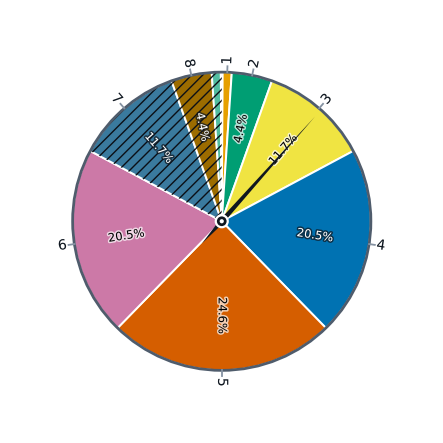

In [2]:
Binomial(10, 0.5).spinner()

The widest slice is 5, which is also the most likely number of heads in ten
coin flips. The percentages inside the slices are the probabilities, and the
numbers around the rim are the outcomes.

## What did it land on?

Calling `.spinner()` spins it. The value the needle landed on comes back as
`.value`.

5

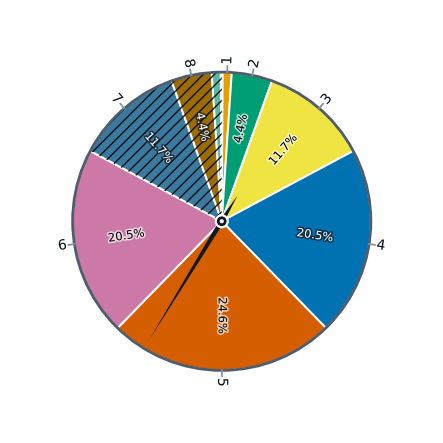

In [3]:
spin = Binomial(10, 0.5).spinner()
spin.value

## The same spin every time

Spin again and the needle lands somewhere else. Pass a `seed` when you want
the same picture back -- handy for slides and homework solutions.

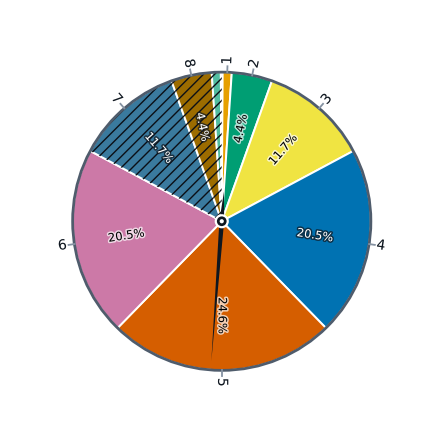

In [4]:
Binomial(10, 0.5).spinner(seed=1)

## Pointing at a value you choose

Sometimes you don't want a random spin at all -- you want to show where a
particular outcome sits. Pass `value` and the needle goes there.

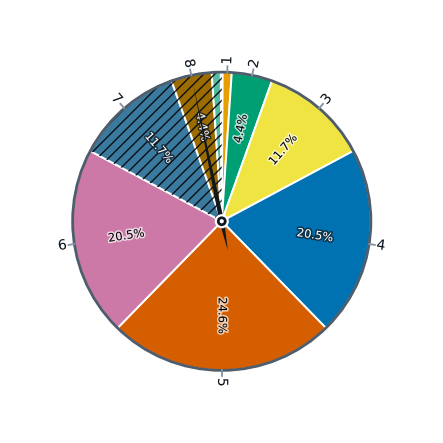

In [5]:
Binomial(10, 0.5).spinner(value=8)

Notice how thin that slice is. Eight heads out of ten is possible, but the
needle has very little room to land on it.

## A fair die

Six outcomes, all equally likely, so all six slices are the same size.

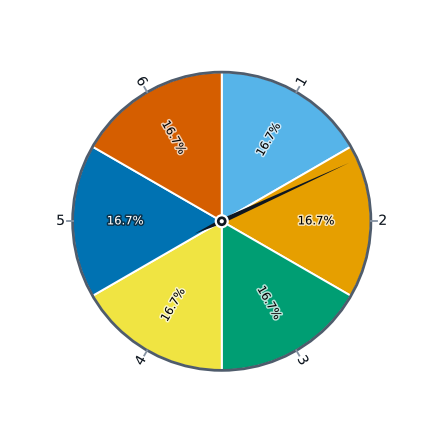

In [6]:
DiscreteUniform(1, 6).spinner()

## Distributions with a tail

A Poisson or a Geometric has infinitely many outcomes, so the spinner shows
the ones that carry essentially all the probability -- the same range you
would see if you plotted it.

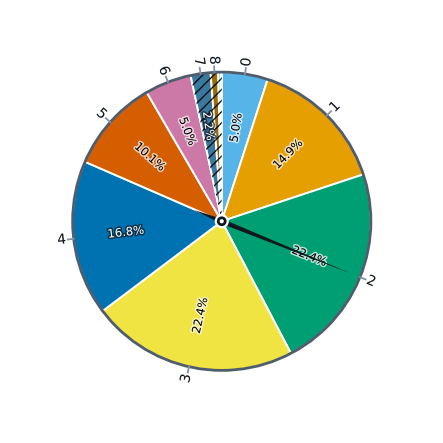

In [7]:
Poisson(3).spinner(value=2)

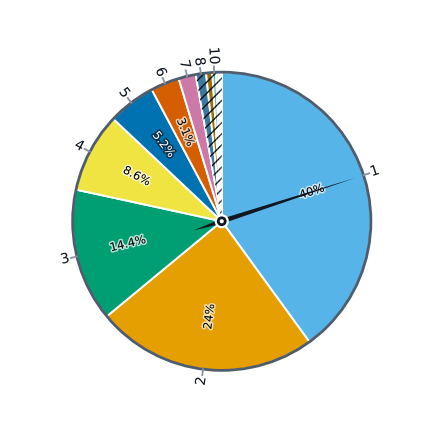

In [8]:
Geometric(0.4).spinner(value=1)

The Geometric's slices shrink geometrically, which is easier to see here than
in a table of numbers.

## When there are more outcomes than colors

The palette has seven colors. Past that, the spinner reuses them at a
different lightness and adds a hatch, so no two neighbouring slices ever look
the same.

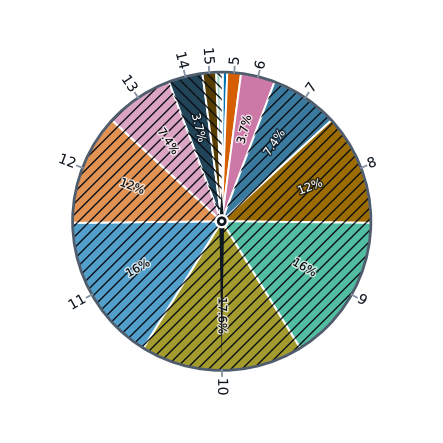

In [9]:
Binomial(20, 0.5).spinner(value=10)

## A continuous distribution

A continuous distribution has no outcomes to slice up -- every value has
probability zero. So instead the rim becomes a **ruler**, marked at round
values, and the slice between two marks is the probability of landing in that
range.

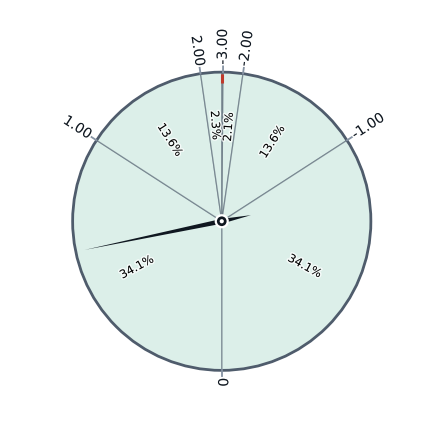

In [10]:
Normal(0, 1).spinner()

Read it as a picture of where the probability is. Every band is one unit wide,
but they are nowhere near the same size: -1 to 0 takes 34.1% of the circle,
while 1 to 2 takes only 13.6%. Same width in value, very different chance --
which is what "the density is higher in the middle" means.

## Choosing how many bands

`sections` says roughly how many bands you want. It is a request rather than
an order -- the spinner snaps to the nearest tidy step (0.5 here, not 0.515),
so the count you get can differ a little from the one you asked for.

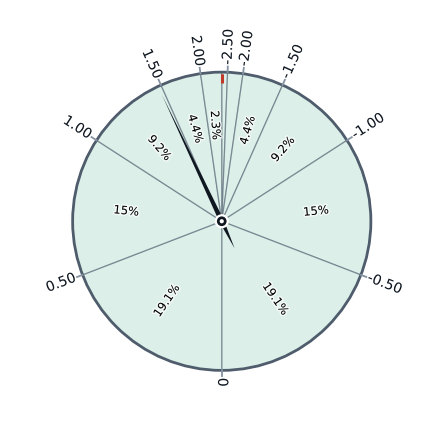

In [11]:
Normal(0, 1).spinner(sections=12)

## Or setting the step yourself

Pass `increment` instead to say how wide each band is, in the units of the
distribution.

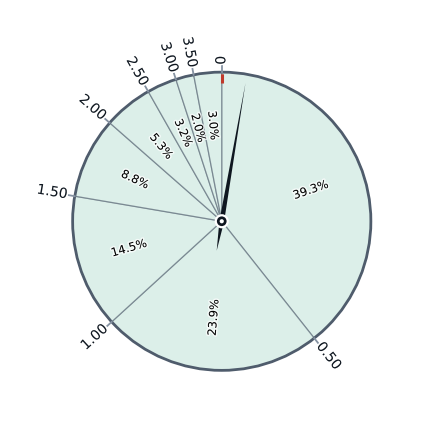

In [12]:
Exponential(1).spinner(increment=0.5)

The bands get thinner and thinner going clockwise. An exponential waiting
time is most likely to be short, so most of the circle is given to the small
values.

## The other way to read a continuous spinner

`style="area"` turns the idea inside out. Instead of equal steps in *value*,
every slice is the same *size* -- so every slice is equally likely, and the
numbers on the rim are wherever they have to be to make that true.

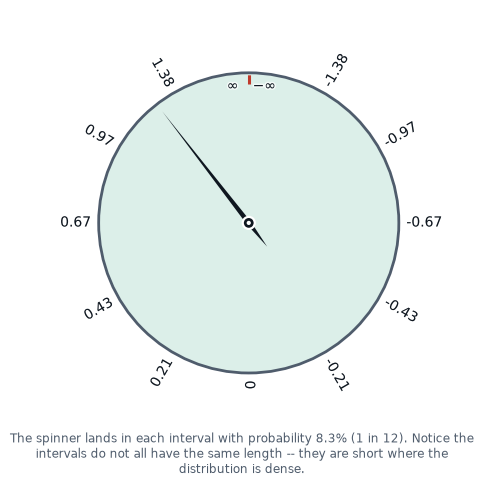

In [13]:
Normal(0, 1).spinner(style="area")

Look at how the numbers bunch up near 0 and spread out towards the tails.
Every slice is a 1-in-12 chance, but the middle slices cover a narrow range
of values and the outer ones cover a wide one. Where the distribution is
dense, you don't need much room to collect the same amount of probability.

The two ends meet at 12 o'clock, marked with the dashed red line -- that is
where the largest values wrap back round to the smallest.

Twelve slices is the default, like the hours on a clock face, but you can ask
for anywhere from 4 to 60.

## Four slices: the quartiles

With only four equally likely slices, the boundaries have to be the
**quartiles**.

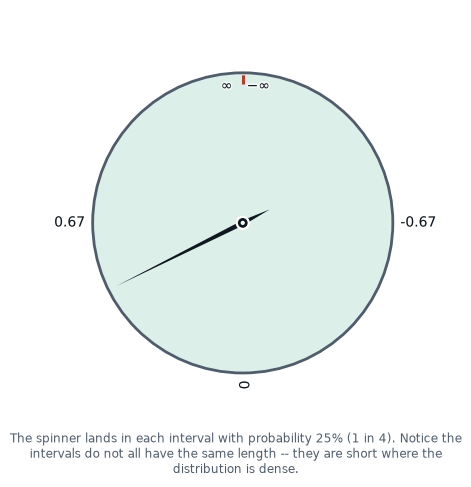

In [14]:
Normal(0, 1).spinner(style="area", sections=4)

And those are numbers you can check straight off the distribution:

In [15]:
X = Normal(0, 1)
X.quantile(0.25), X.quantile(0.5), X.quantile(0.75)

(np.float64(-0.6744897501960817),
 np.float64(0.0),
 np.float64(0.6744897501960817))

Those are the three numbers on the rim, at 3, 6 and 9 o'clock. That is the
quarter-turn property from the top of this notebook, visible in one picture.

## Spinning really is simulating

The slices are the distribution, so spinning many times gives the same thing
as simulating. Here is the distribution the spinner above encodes, simulated
and drawn the ordinary way:

Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


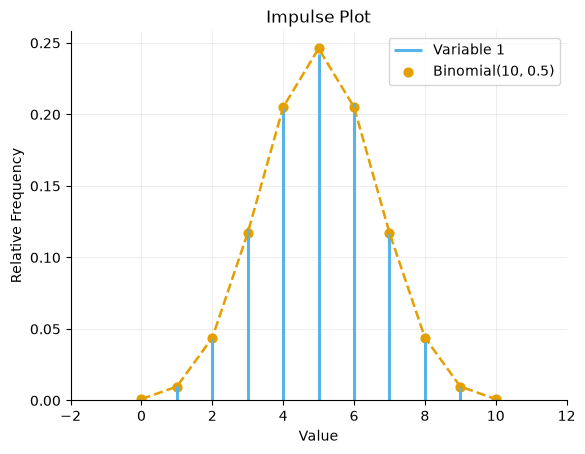

In [16]:
RV(Binomial(10, 0.5)).sim(10000).plot()
Binomial(10, 0.5).plot()

The heights here are the slice sizes on the very first spinner in this
notebook.

## Two spinners side by side

Pass `ax` to put a spinner on axes you made yourself, which is how to compare
two of them.

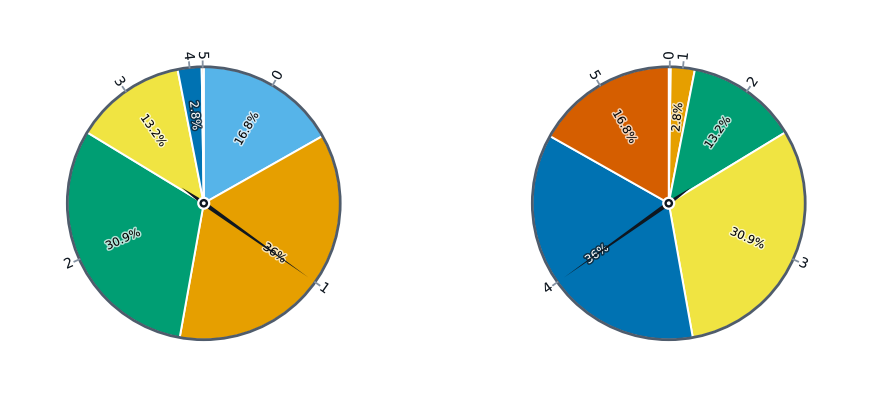

In [17]:
import matplotlib.pyplot as plt

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 5.5))
Binomial(5, 0.3).spinner(value=1, ax=left)
Binomial(5, 0.7).spinner(value=4, ax=right)

The two dials are mirror images. `p = 0.3` gives most of the circle to the
small outcomes and `p = 0.7` gives it to the large ones, so the slice for 1 on
the left is exactly the size of the slice for 4 on the right.

## Things the spinner will tell you off for

A discrete spinner has only one layout, so there is no style to pick:

In [18]:
try:
    Binomial(10, 0.5).spinner(style="area")
except ValueError as e:
    print("ValueError:", e)

ValueError: A discrete distribution has only one spinner dial -- one slice per outcome, sized by its probability -- so it takes no style. Drop the style= argument, or use it on a continuous distribution, where it chooses between 'increments' and 'area'.


An equal-area dial labels every boundary, so it caps how many slices it will
draw:

In [19]:
try:
    Normal(0, 1).spinner(style="area", sections=100)
except ValueError as e:
    print("ValueError:", e)

ValueError: sections=100 is not a section count style='area' can draw. Use a whole number from 4 to 60. Past 60 slices, two of the values round the rim sit closer together than a label is tall, and an equal-area dial never drops one -- every slice is the same chance, so every boundary has to say where it is.


And a distribution over vectors has no single value for a needle to land on:

In [20]:
try:
    MultivariateNormal(mean=[0, 0], cov=[[1, 0], [0, 1]]).spinner()
except ValueError as e:
    print("ValueError:", e)

ValueError: A MultivariateNormal has no spinner. It is a distribution over vectors or matrices, so there is no single value for a needle to land on. Spin one component at a time instead.


## Summary

| What you want | How to ask |
|---|---|
| Spin it | `X.spinner()` |
| The value it landed on | `X.spinner().value` |
| The same spin again | `X.spinner(seed=1)` |
| Point at a value | `X.spinner(value=7)` |
| Round bands (continuous, default) | `X.spinner(style="increments")` |
| Equally likely slices | `X.spinner(style="area")` |
| How many bands or slices | `X.spinner(sections=12)` |
| How wide each band | `X.spinner(increment=0.5)` |
| Draw on your own axes | `X.spinner(ax=ax)` |